# Cruzamento: agenda discursiva × agenda legislativa (Fase 6 — parte 2)

Com os discursos já classificados (notebook 05), cruzamos, por deputado e por partido, o que
cada um **fala** (temas dos discursos) com o que **propõe** (temas das proposições):

- **B1 — "Fala vs. Faz" (por deputado):** quem fala muito de um tema mas propõe pouco (ou o inverso).
- **B2 — por partido/UF:** onde cada partido fala mais do que legisla, e vice-versa.

⚠️ Análise **agregada e exploratória** (não causal). Como o rótulo de um discurso é ruidoso
(*domain shift*), olhamos só o agregado e **privilegiamos os temas confiáveis** medidos em
`resultados_dominio.csv` (notebook 05).

> Pré-requisitos: `discursos_classificados.csv`, `proposicoes_parlamentares.csv`,
> `proposicoes_temas.csv`, `parlamentares.csv`, `resultados_dominio.csv`. `pip install matplotlib pandas`.

## Passo 1 — Montar as duas "agendas" (perfil temático normalizado)
Para cada deputado, entre os **temas confiáveis**, calculamos a **fatia de atenção** em cada
tema — nos **discursos** (`share_disc`) e nas **proposições** (`share_prop`). Cada perfil
**soma 1**, então os dois lados ficam comparáveis e o **viés de sobre-rotulação** dos discursos
(o modelo marca ~6 temas/discurso) se **cancela** na normalização. `gap = fala − propõe`.

In [3]:
import os
os.makedirs("dados", exist_ok=True)
import pandas as pd, numpy as np

parl = pd.read_csv("dados/parlamentares.csv", sep=";", dtype=str).rename(columns={"id": "id_deputado"})

# temas confiaveis (do domain shift): o perfil e normalizado DENTRO deles
dom = pd.read_csv("dados/resultados_dominio.csv")
CORTE = 0.50
temas_confiaveis = dom.loc[dom["f1_discurso"] >= CORTE, "tema"].tolist()

# ---- DISCURSOS ----
dc = pd.read_csv("dados/discursos_classificados.csv", sep=";", dtype=str)
n_disc = dc.groupby("id_deputado").size().rename("n_disc")        # volume (nº de discursos)
dce = dc.assign(tema=dc["temas_previstos"].fillna("").str.split("|")).explode("tema")
dce = dce[dce["tema"].isin(temas_confiaveis)]                     # so temas confiaveis
disc_cnt = dce.groupby(["id_deputado", "tema"]).size().rename("c").reset_index()
# PERFIL normalizado: fatia de atencao entre os temas confiaveis (soma 1 por deputado)
disc_cnt["share_disc"] = disc_cnt["c"] / disc_cnt.groupby("id_deputado")["c"].transform("sum")

# ---- PROPOSICOES ----
pp = pd.read_csv("dados/proposicoes_parlamentares.csv", sep=";", dtype=str).merge(
     pd.read_csv("dados/proposicoes_temas.csv", dtype=str)[["id", "temas"]],
     left_on="proposicao_id", right_on="id")
n_pl = pp.groupby("id_autor")["proposicao_id"].nunique().rename("n_pl")   # volume (nº de PLs)
ppe = pp.assign(tema=pp["temas"].str.split("|")).explode("tema").rename(columns={"id_autor": "id_deputado"})
ppe = ppe[ppe["tema"].isin(temas_confiaveis)]
prop_cnt = ppe.groupby(["id_deputado", "tema"]).size().rename("c").reset_index()
prop_cnt["share_prop"] = prop_cnt["c"] / prop_cnt.groupby("id_deputado")["c"].transform("sum")

# ---- juntar as duas agendas (perfis comparaveis: cada um soma 1 por deputado) ----
ag = pd.merge(disc_cnt[["id_deputado", "tema", "share_disc"]],
              prop_cnt[["id_deputado", "tema", "share_prop"]],
              on=["id_deputado", "tema"], how="outer")
ag[["share_disc", "share_prop"]] = ag[["share_disc", "share_prop"]].fillna(0.0)
ag = ag.merge(parl[["id_deputado", "nome", "siglaPartido", "siglaUf"]], on="id_deputado", how="left")
ag["gap"] = ag["share_disc"] - ag["share_prop"]      # >0 fala (proporcionalmente) mais do que propoe
print(f"{len(temas_confiaveis)} temas confiaveis | linhas (deputado x tema): {len(ag)}")
ag.head()

20 temas confiaveis | linhas (deputado x tema): 8281


,id_deputado,tema,share_disc,share_prop,nome,siglaPartido,siglaUf,gap
0,104552,"Agricultura, Pecuária, Pesca e Extrativismo",0.014286,0.007937,Socorro Neri,PP,AC,0.006349
1,104552,"Arte, Cultura e Religião",0.014286,0.015873,Socorro Neri,PP,AC,-0.001587
2,104552,Comunicações,0.014286,0.015873,Socorro Neri,PP,AC,-0.001587
3,104552,Defesa e Segurança,0.042857,0.055556,Socorro Neri,PP,AC,-0.012698
4,104552,Direito Penal e Processual Penal,0.028571,0.063492,Socorro Neri,PP,AC,-0.034921


**Temas confiáveis** (do domain shift): só interpretamos a fundo os temas em que o modelo
ainda vai razoavelmente bem nos discursos. Definimos um corte simples sobre `f1_discurso`.

In [4]:
print(f"{len(temas_confiaveis)} temas confiaveis (f1_discurso >= {CORTE}) usados no cruzamento:")
for t in temas_confiaveis:
    print("  -", t)

20 temas confiaveis (f1_discurso >= 0.5) usados no cruzamento:
  - Direito e Defesa do Consumidor
  - Relações Internacionais e Comércio Exterior
  - Economia
  - Viação, Transporte e Mobilidade
  - Turismo
  - Meio Ambiente e Desenvolvimento Sustentável
  - Direito Penal e Processual Penal
  - Comunicações
  - Educação
  - Trabalho e Emprego
  - Agricultura, Pecuária, Pesca e Extrativismo
  - Energia, Recursos Hídricos e Minerais
  - Finanças Públicas e Orçamento
  - Defesa e Segurança
  - Saúde
  - Previdência e Assistência Social
  - Esporte e Lazer
  - Direitos Humanos e Minorias
  - Arte, Cultura e Religião
  - Estrutura Fundiária


## Passo 2 — B1: "Fala vs. Faz" (por deputado)
Para um tema, cada ponto é um deputado: eixo X = quanto **propõe**, eixo Y = quanto **fala**.
Acima da diagonal = "fala mais do que propõe"; abaixo = "propõe mais do que fala".

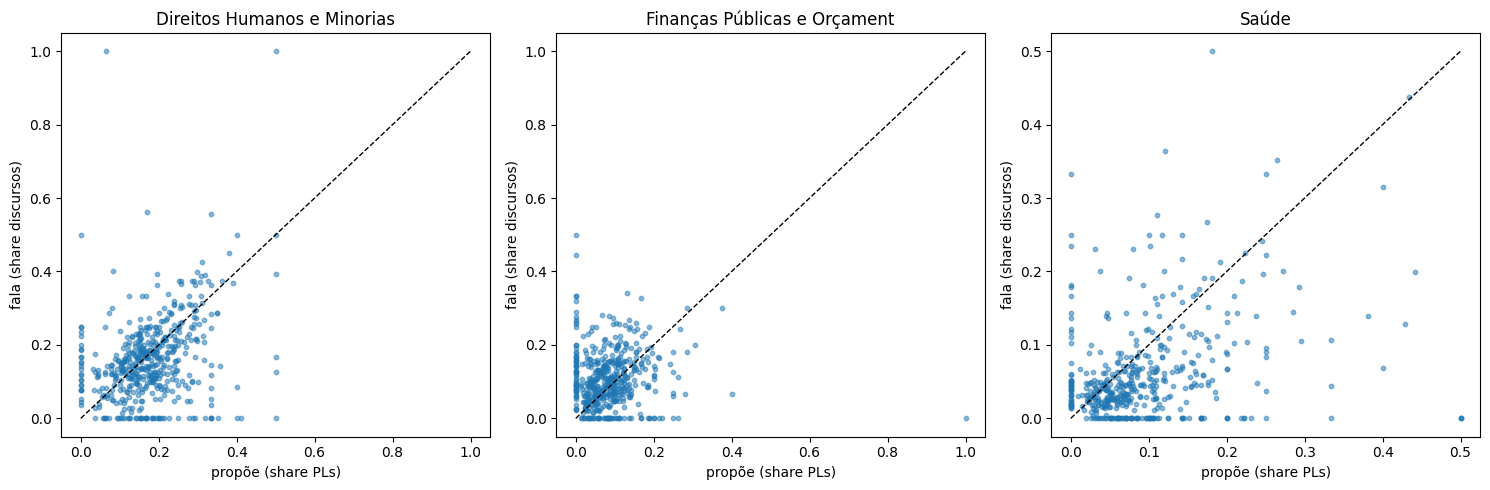

Salvo: figuras/fala_vs_faz.png — temas: ['Direitos Humanos e Minorias', 'Finanças Públicas e Orçamento', 'Saúde']


In [5]:
import matplotlib.pyplot as plt, os
os.makedirs("figuras", exist_ok=True)

# escolhe 3 temas confiaveis com bastante deputado para ilustrar
cont = ag[ag["tema"].isin(temas_confiaveis)].groupby("tema")["id_deputado"].nunique()
temas_plot = list(cont.sort_values(ascending=False).head(3).index)

fig, axes = plt.subplots(1, len(temas_plot), figsize=(5*len(temas_plot), 5))
if len(temas_plot) == 1: axes = [axes]
for ax, tema in zip(axes, temas_plot):
    d = ag[ag["tema"] == tema]
    ax.scatter(d["share_prop"], d["share_disc"], s=10, alpha=0.5)
    lim = max(d["share_prop"].max(), d["share_disc"].max(), 0.01)
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlabel("propõe (share PLs)"); ax.set_ylabel("fala (share discursos)")
    ax.set_title(tema[:28])
plt.tight_layout()
plt.savefig("figuras/fala_vs_faz.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: figuras/fala_vs_faz.png — temas:", temas_plot)

**Ranking dos maiores descompassos** por tema (confiável): quem mais *fala além do que
propõe* (gap alto) e o inverso. Filtramos deputados com volume mínimo para evitar ruído.

In [6]:
MIN_DISC, MIN_PL = 20, 5
nd = n_disc.reset_index()                                   # id_deputado, n_disc
npl = n_pl.rename_axis("id_deputado").reset_index()         # id_deputado, n_pl
forte = ag.merge(nd, on="id_deputado").merge(npl, on="id_deputado", how="left")
forte = forte[(forte["n_disc"] >= MIN_DISC) & (forte["n_pl"].fillna(0) >= MIN_PL)
              & forte["tema"].isin(temas_confiaveis)]

ranking = forte.sort_values("gap", ascending=False)[
    ["nome", "siglaPartido", "siglaUf", "tema", "share_disc", "share_prop", "gap"]].round(3)
ranking.to_csv("dados/fala_vs_faz.csv", index=False, encoding="utf-8")
print("Salvo: dados/fala_vs_faz.csv\n")
print("== FALA muito mais do que PROPÕE ==")
print(ranking.head(10).to_string(index=False))
print("\n== PROPÕE muito mais do que FALA ==")
print(ranking.tail(10).to_string(index=False))

Salvo: fala_vs_faz.csv

== FALA muito mais do que PROPÕE ==
                  nome siglaPartido siglaUf                            tema  share_disc  share_prop   gap
         Pastor Eurico         PSDB      PE        Arte, Cultura e Religião       0.393       0.037 0.356
        Filipe Martins           PL      TO        Arte, Cultura e Religião       0.323       0.045 0.277
       Moses Rodrigues        UNIÃO      CE   Finanças Públicas e Orçamento       0.267       0.000 0.267
                Bebeto           PP      RJ Viação, Transporte e Mobilidade       0.313       0.048 0.266
       Raimundo Santos          PSD      PA        Arte, Cultura e Religião       0.318       0.058 0.260
           Vitor Lippi          PSD      SP                        Economia       0.333       0.074 0.259
Carlos Henrique Gaguim        UNIÃO      TO Viação, Transporte e Mobilidade       0.250       0.023 0.227
          Rubens Otoni           PT      GO Viação, Transporte e Mobilidade       0.296     

## Passo 3 — B2: por partido (fala − propõe, por tema)
Agregamos no nível do **partido** (prevalência do tema entre todos os discursos vs. todas as
PLs do partido) e mostramos a **diferença** num mapa de calor: vermelho = fala mais do que
legisla; azul = legisla mais do que fala.

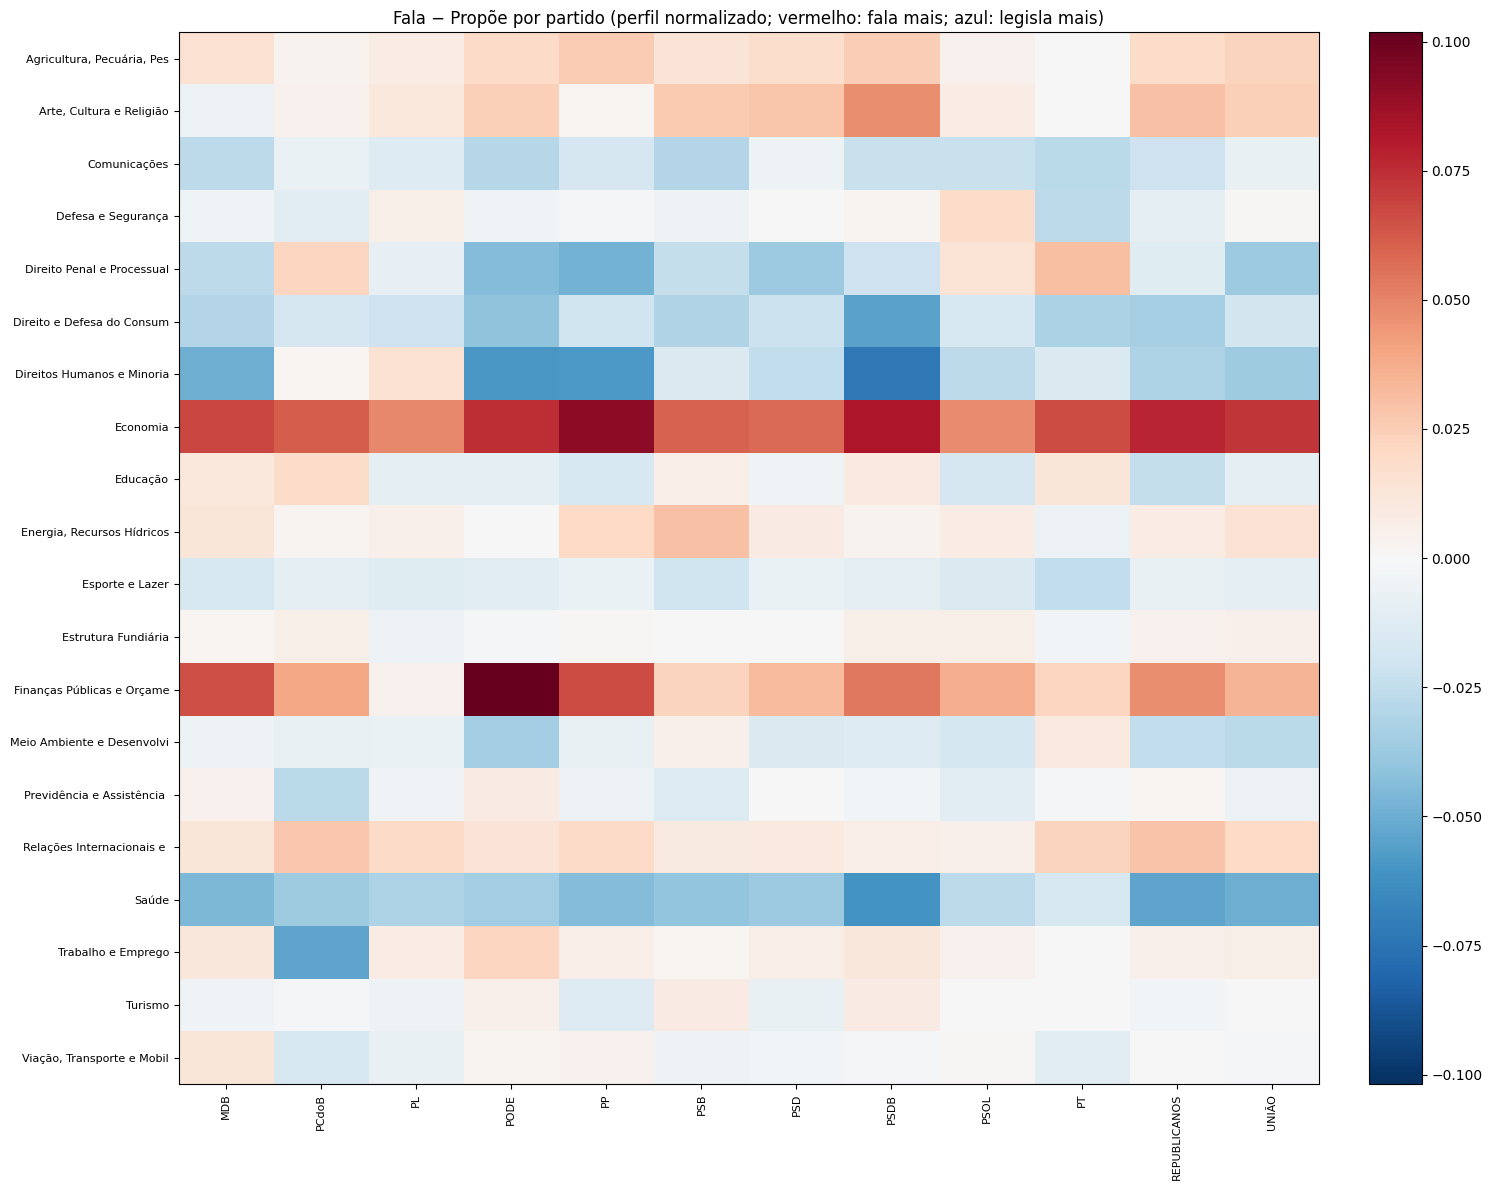

Salvo: figuras/heatmap_partido.png


In [7]:
import matplotlib.pyplot as plt
parts = parl[["id_deputado", "siglaPartido"]]

# perfil normalizado por PARTIDO (dentro dos temas confiaveis; dce/ppe ja filtrados)
# .div(..., level="siglaPartido") alinha o denominador (1 nivel) ao numerador (2 niveis)
dce_p = dce.merge(parts, on="id_deputado")
disc_part = (dce_p.groupby(["siglaPartido", "tema"]).size()
             .div(dce_p.groupby("siglaPartido").size(), level="siglaPartido")
             .rename("share_disc").reset_index())
ppe_p = ppe.merge(parts, on="id_deputado")
prop_part = (ppe_p.groupby(["siglaPartido", "tema"]).size()
             .div(ppe_p.groupby("siglaPartido").size(), level="siglaPartido")
             .rename("share_prop").reset_index())

pp_ag = disc_part.merge(prop_part, on=["siglaPartido", "tema"], how="outer").fillna(0)
pp_ag["dif"] = pp_ag["share_disc"] - pp_ag["share_prop"]

# partidos com mais deputados (evita siglas minusculas)
grandes = parl["siglaPartido"].value_counts().head(12).index.tolist()
M = (pp_ag[pp_ag["siglaPartido"].isin(grandes)]
     .pivot(index="tema", columns="siglaPartido", values="dif").fillna(0))

fig, ax = plt.subplots(figsize=(1.0*len(M.columns)+3, 0.5*len(M.index)+2))
vmax = np.abs(M.values).max() or 0.01
im = ax.imshow(M.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(M.columns))); ax.set_xticklabels(M.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(M.index))); ax.set_yticklabels([t[:26] for t in M.index], fontsize=8)
ax.set_title("Fala − Propõe por partido (perfil normalizado; vermelho: fala mais; azul: legisla mais)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("figuras/heatmap_partido.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: figuras/heatmap_partido.png")

## Passo 4 — Plausibilidade e leitura crítica
Validação de face: os deputados/partidos que mais **falam** de um tema fazem sentido?

In [8]:
for tema in temas_plot:
    top = (ag[ag["tema"] == tema].merge(n_disc.reset_index(), on="id_deputado")
           .query("n_disc >= 20").sort_values("share_disc", ascending=False).head(5))
    print(f"\nTema: {tema} — quem mais FALA (perfil, share de atencao):")
    for _, r in top.iterrows():
        print(f"  {r['nome']:<28} {r['siglaPartido']}/{r['siglaUf']}  {r['share_disc']:.2f}")


Tema: Direitos Humanos e Minorias — quem mais FALA (perfil, share de atencao):
  Amanda Gentil                PP/MA  0.45
  Daiana Santos                PCdoB/RS  0.43
  Célia Xakriabá               PSOL/MG  0.40
  Marcio Alvino                PL/SP  0.39
  Helio Lopes                  PL/RJ  0.39

Tema: Finanças Públicas e Orçamento — quem mais FALA (perfil, share de atencao):
  Pedro Paulo                  PSD/RJ  0.34
  Mauro Benevides Filho        UNIÃO/CE  0.33
  Claudio Cajado               PP/BA  0.32
  Aguinaldo Ribeiro            PP/PB  0.29
  Átila Lira                   PP/PI  0.28

Tema: Saúde — quem mais FALA (perfil, share de atencao):
  Dr. Daniel Soranz            PSD/RJ  0.44
  Bruno Farias                 REPUBLICANOS/MG  0.35
  Weliton Prado                PSD/MG  0.31
  Beto Preto                   PSD/PR  0.28
  Dr. Zacharias Calil          MDB/GO  0.27


**Ressalvas para o relatório:** (1) análise **exploratória/descritiva**, não causal;
(2) rótulo de discurso é ruidoso sob *domain shift* → interpretamos só o **agregado** e os
**temas confiáveis** (`resultados_dominio.csv`); (3) usamos **perfil temático normalizado** —
`fala` e `propõe` são a *fatia de atenção* do deputado entre os temas confiáveis (cada perfil
soma 1), o que **cancela** o viés de sobre-rotulação dos discursos e torna a comparação justa.

---
**Fim da Fase 6.** Entregáveis para os slides: `figuras/fala_vs_faz.png`,
`figuras/heatmap_partido.png`, `fala_vs_faz.csv` e (do notebook 05) `resultados_dominio.csv`.